In [1]:
print('hello')

hello


In [2]:
# standard python
import os
import json
import time
import random
import warnings
import csv
from datetime import datetime

# external libs
import pandas as pd
import requests
from tqdm.notebook import tqdm

# beautiful soup
from bs4 import BeautifulSoup

# selenium
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
# selenium with undetected tracking
import undetected_chromedriver as uc

# better visualization in terminal
from IPython.display import display, Image, HTML, clear_output
from PIL import Image as PILImage
from colorama import Fore, Style, init

# no warnings
warnings.filterwarnings("ignore", message="Pyarrow will become a required dependency")


# 0 - Webscrapping demo

## A - Functions

In [3]:
# type with human effect function (just for style)
def type_with_human_effect(element, text, min_delay=0.05, max_delay=0.15):
    """texting with random time between keys so that it's almost like a human (only for display)"""
    for char in text:
        element.send_keys(char)
        time.sleep(random.uniform(min_delay, max_delay))

# scrolling function
def smooth_scroll(driver, scroll_to=None, duration=2, steps=25):
    """scrolling the page"""
    # continue until the end of the page
    if scroll_to is None:
        total_height = driver.execute_script("return document.body.scrollHeight")
    else:
        total_height = scroll_to
    
    current_position = driver.execute_script("return window.pageYOffset")
    step_size = (total_height - current_position) / steps
    
    for i in range(steps):
        new_position = current_position + step_size * (i + 1)
        driver.execute_script(f"window.scrollTo(0, {new_position})")
        time.sleep(duration / steps)

# screenshot function
def take_and_display_screenshot(driver, filename="screenshot.png", width=800):
    """take a screenshot and show it in the notebook"""
    driver.save_screenshot(filename)
    
    # resizing the image to display it
    img = PILImage.open(filename)
    wpercent = (width / float(img.size[0]))
    hsize = int((float(img.size[1]) * float(wpercent)))
    img = img.resize((width, hsize), PILImage.LANCZOS)
    img.save(filename)
    
    # display image
    display(Image(filename=filename, width=width))

# highlight elements
def highlight_element(driver, element, duration=2):
    """highlights an element in the page to better follow (only for display)"""
    original_style = element.get_attribute("style")
    driver.execute_script("""
    arguments[0].setAttribute('style', arguments[1] + 
        '; border: 2px solid red; background: yellow; color: black;');
    """, element, original_style)
    time.sleep(duration)
    driver.execute_script("""
    arguments[0].setAttribute('style', arguments[1]);
    """, element, original_style)


## B - Example of Browser - Filling out a form

browser configuration...


Webdriver init:   0%|          | 0/10 [00:00<?, ?it/s]


📝 Filling out a Form


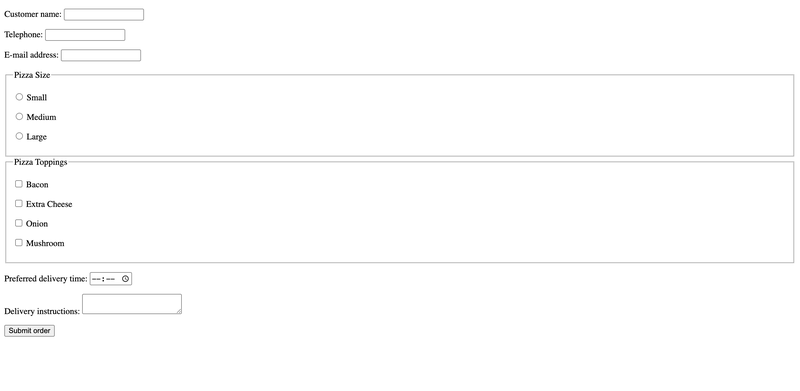

...


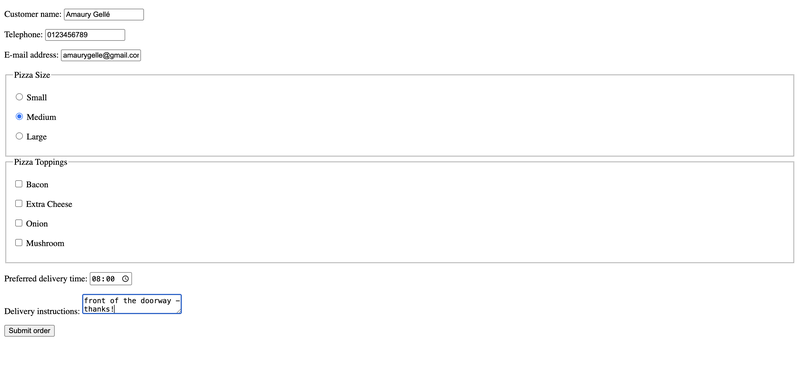

Soumission du formulaire...
Erreur lors du remplissage du formulaire: Message: no such element: Unable to locate element: {"method":"css selector","selector":"button[type='submit']"}
  (Session info: chrome=146.0.7680.154); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#no-such-element-exception
Stacktrace:
0   chromedriver                        0x000000010331aa80 cxxbridge1$str$ptr + 3158700
1   chromedriver                        0x0000000103312b08 cxxbridge1$str$ptr + 3126068
2   chromedriver                        0x0000000102de7724 _RNvCskE0kXQ3GIWk_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 75036
3   chromedriver                        0x0000000102e2f604 _RNvCskE0kXQ3GIWk_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 369660
4   chromedriver                        0x0000000102e6e2f0 _RNvCskE0kXQ3GIWk_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 626920
5   chromedriver                        0x

In [4]:
# colorama init for terminal
init()

# setting up the browser
print(f"{Fore.CYAN}browser configuration...{Style.RESET_ALL}")

# compatible options with undetected browser
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")  # full screen window
options.add_argument("--disable-notifications")  # no notifs

# progress bar
for i in tqdm(range(10), desc="Webdriver init"):
    time.sleep(0.2)

# webdriver init with undetected lib (to avoid robots warnings from google)
driver = webdriver.Chrome(options=options)

print(f"\n{Fore.CYAN}📝 Filling out a Form{Style.RESET_ALL}")
driver.get("https://httpbin.org/forms/post")
time.sleep(2)
take_and_display_screenshot(driver, "form_initial.png")

print("...")

# Remplir les champs du formulaire avec un effet visuel
try:
    # Nom du client
    customer_name = driver.find_element(By.NAME, "custname")
    highlight_element(driver, customer_name)
    type_with_human_effect(customer_name, "Amaury Gellé")
    
    # Téléphone
    phone = driver.find_element(By.NAME, "custtel")
    highlight_element(driver, phone)
    type_with_human_effect(phone, "0123456789")
    
    # Email
    email = driver.find_element(By.NAME, "custemail")
    highlight_element(driver, email)
    type_with_human_effect(email, "amaurygelle@gmail.com")
    
    # Choix de pizza
    pizza_choice = driver.find_element(By.CSS_SELECTOR, "input[value='medium']")
    highlight_element(driver, pizza_choice)
    pizza_choice.click()
    
    # Garniture
    toppings = driver.find_element(By.NAME, "topping")
    highlight_element(driver, toppings)
    driver.execute_script("arguments[0].value = 'mushroom';", toppings)
    
    # Heure de livraison
    time_elem = driver.find_element(By.NAME, "delivery")
    highlight_element(driver, time_elem)
    type_with_human_effect(time_elem, "18:30")
    
    # Instructions
    instructions = driver.find_element(By.NAME, "comments")
    highlight_element(driver, instructions)
    type_with_human_effect(instructions, "Please leave it in front of the doorway - thanks!")
    
    take_and_display_screenshot(driver, "form_filled.png")
    
    # Soumission du formulaire
    print("Soumission du formulaire...")
    submit_button = driver.find_element(By.CSS_SELECTOR, "button[type='submit']")
    highlight_element(driver, submit_button)
    submit_button.click()
    
    time.sleep(2)
    take_and_display_screenshot(driver, "form_submitted.png")
    
except Exception as e:
    print(f"Erreur lors du remplissage du formulaire: {e}")

## C - Mimicking a Google search

browser configuration...


Webdriver init:   0%|          | 0/10 [00:00<?, ?it/s]

Interactive Google Search
Opening Google and accepting cookies...
No cookies found or cookies already accepted
Looking: 'Albert School data courses'


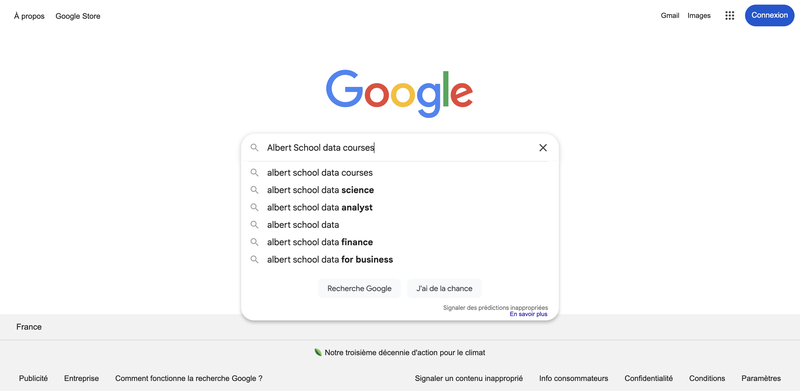

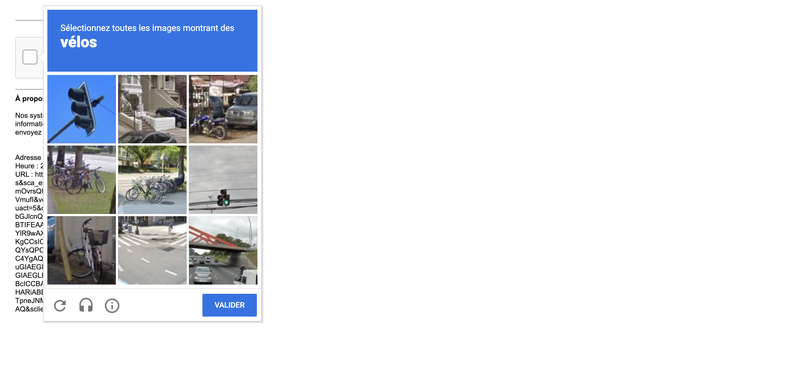

Scrolling the page...


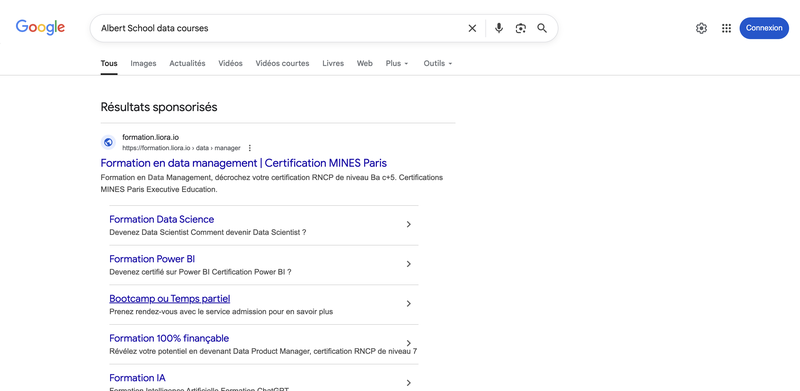

 Extracting links and descriptions...
Loaded ✓
Links found: 19

Looking at firt results (17 au total):

Résultat 1:
Title: Formation en data management | Certification MINES Paris
formation.liora.io
https://formation.liora.io › data › manager
URL: https://formation.liora.io/data-product-manager
Description: No description found...

Résultat 2:
Title: Formation Data Science
Devenez Data Scientist Comment devenir Data Scientist ?
URL: https://formation.liora.io/data-scientist
Description: No description found...

Résultat 3:
Title: Formation Power BI
Devenez certifié sur Power BI Certification Power BI ?
URL: https://formation.liora.io/power-bi
Description: No description found...

Exported results in google_search_results_20260320_152558.csv (17 entrées)

Exportation terminée!


Finalisation:   0%|          | 0/5 [00:00<?, ?it/s]

In [5]:
# colorama init for terminal
init()

# setting up the browser
print(f"{Fore.CYAN}browser configuration...{Style.RESET_ALL}")

# compatible options with undetected browser
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")  # full screen window
options.add_argument("--disable-notifications")  # no notifs

# progress bar
for i in tqdm(range(10), desc="Webdriver init"):
    time.sleep(0.2)

# webdriver init with undetected lib (to avoid robots warnings from google)
driver = webdriver.Chrome(options=options)

print(f"{Fore.GREEN}Interactive Google Search{Style.RESET_ALL}")
print("Opening Google and accepting cookies...")

# Ouverture de Google
driver.get("https://www.google.com")
time.sleep(2)

# Accept cookies if we have to (might have been done in the past)
try:
    cookie_button = WebDriverWait(driver, 5).until(
        EC.element_to_be_clickable((By.XPATH, "//button[contains(., 'Accept all')]"))
    )
    cookie_button.click()
    print("Cookies accepted ✓")
    time.sleep(1)
except:
    print("No cookies found or cookies already accepted")

# Typing with human-like behavior
search_box = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.NAME, "q"))
)

driver.execute_script("arguments[0].scrollIntoView(true);", search_box)
time.sleep(1)

# parfois google a besoin qu'on clique d'abord dans la barre
search_box.click()
time.sleep(1)

# on vide le champ au cas où
search_box.clear()

search_term = "Albert School data courses"
print(f"Looking: '{search_term}'")

type_with_human_effect(search_box, search_term)
take_and_display_screenshot(driver, "google_search_typing.png")

# Submitting the request
search_box.send_keys(Keys.RETURN)
time.sleep(3)
take_and_display_screenshot(driver, "google_results.png")

# Scrolling the page and taking screenshots
print("Scrolling the page...")
smooth_scroll(driver, duration=4)
take_and_display_screenshot(driver, "google_results_scrolled.png")

# Extracting data
print(f"{Fore.BLUE} Extracting links and descriptions...{Style.RESET_ALL}")

# Waiting for the elements of the page to have loaded
try:
    WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "a[href^='https://']"))
    )
    print("Loaded ✓")
except:
    print("Timeout for research terms")

# collect search results
search_results = []
time.sleep(1)

# Look for all elements
links = driver.find_elements(By.CSS_SELECTOR, "a[href^='https://']:not([href*='google'])")

print(f"Links found: {len(links)}")

for link in links:
    try:
        # get the URL
        url = link.get_attribute("href")
        
        # Get the text of the link
        title = link.text
        
        # if there is no title, get its parent element 
        if not title.strip():
            try:
                h3 = link.find_element(By.XPATH, "./ancestor::*//h3 | .//*//h3 | ./following::h3[1] | ./preceding::h3[1]")
                title = h3.text
            except:
                title = "No title found"
        
        # Find descriptions
        description = "No description found"
        try:
            desc_candidates = [
                link.find_element(By.XPATH, "./ancestor::*[3]//div[string-length(text()) > 50]"),
                link.find_element(By.XPATH, "./following::div[string-length(text()) > 50][1]"),
                link.find_element(By.XPATH, "./ancestor::*//div[contains(@class, 'desc') or contains(@class, 'snippet') or contains(@class, 'description')]")
            ]
            
            for candidate in desc_candidates:
                if candidate and candidate.text.strip():
                    description = candidate.text.strip()
                    break
        except:
            pass  # default value if none
        
        # we only keep rows with at least one non-null value
        if title.strip() and url and "google" not in url.lower():
            search_results.append({
                "Title": title,
                "URL": url,
                "Description": description
            })
    except Exception as e:
        print(f"Error when extracting: {str(e)[:100]}...")
        continue

# No duplicates
unique_results = []
seen_urls = set()
for result in search_results:
    if result["URL"] not in seen_urls:
        seen_urls.add(result["URL"])
        unique_results.append(result)

search_results = unique_results

# Display first results
print(f"\n{Fore.YELLOW}Looking at firt results ({len(search_results)} au total):{Style.RESET_ALL}")
for i, result in enumerate(search_results[:3], 1):
    print(f"\nRésultat {i}:")
    print(f"Title: {result['Title']}")
    print(f"URL: {result['URL']}")
    print(f"Description: {result['Description'][:100]}...")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_filename = f"google_search_results_{timestamp}.csv"

# Writing in csv
with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
    fieldnames = ['Title', 'URL', 'Description']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for result in search_results:
        writer.writerow(result)

print(f"\n{Fore.GREEN}Exported results in {csv_filename} ({len(search_results)} entrées){Style.RESET_ALL}")

print("\nExportation terminée!")
for i in tqdm(range(5), desc="Finalisation"):
    time.sleep(0.3)


# I - Webscrapping IMDB (Beautiful Soup)

## A - Making a request on the Top 250 movies page

In [6]:
# looking at the robots.txt

#https://www.imdb.com/robots.txt


In [7]:
# make a request to the IMDB Top 250 Movies page

# ouvrir la page IMDB
url = "https://www.imdb.com/chart/top/"

# si un ancien driver existe et pose problème, on le relance proprement
try:
    driver.quit()
except:
    pass

# options chrome
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
options.add_argument("--disable-notifications")

# relancer un driver propre
driver = webdriver.Chrome(options=options)

# ouvrir la page
driver.get(url)
time.sleep(3)

# récupérer le HTML
html = driver.page_source

print("page chargée ")

page chargée 


In [8]:
# creating a Beautiful Soup object based on the response.text (the HTML we parsed from the URL)

# parser le HTML
soup = BeautifulSoup(html, "html.parser")

## B - Starting small - retrieving the information of the first movie

In [9]:
# soup.select_one() to fetch the first instance of the element we want to fetch

# récupérer le premier film
first_movie = soup.select_one("li.ipc-metadata-list-summary-item")

print(first_movie)

<li class="ipc-metadata-list-summary-item"><div class="ipc-metadata-list-summary-item__c"><div class="ipc-metadata-list-summary-item__tc"><span aria-disabled="false" class="ipc-metadata-list-summary-item__t ipc-btn--not-interactable"></span><div class="sc-fc35a1ef-1 lmHCrT cli-parent li-compact"><div class="sc-fc35a1ef-0 hTMtRz"><div class="sc-62a56b6a-0 eUlMPU cli-poster-container"><div class="ipc-poster ipc-poster--base ipc-poster--media-radius ipc-poster--wl-true ipc-poster--dynamic-width ipc-sub-grid-item ipc-sub-grid-item--span-2" role="group"><div class="ipc-media ipc-media--poster-27x40 ipc-image-media-ratio--poster-27x40 ipc-media--media-radius ipc-media--base ipc-media--poster-s ipc-poster__poster-image ipc-media__img" style="width:100%"><img alt="Tim Robbins in Les Évadés (1994)" class="ipc-image" loading="lazy" sizes="50vw, (min-width: 480px) 34vw, (min-width: 600px) 26vw, (min-width: 1024px) 16vw, (min-width: 1280px) 16vw" src="https://m.media-amazon.com/images/M/MV5BMDAyY2

In [10]:
# récupérer le titre
first_title = first_movie.select_one("h3").text

print(first_title)

Les Évadés


In [11]:
# fetch the first year

first_year = first_movie.select_one("span.cli-title-metadata-item").text

print(first_year)


1994


In [12]:
# fetch the first rating

first_rating = first_movie.select_one("span.ipc-rating-star--rating").text

print(first_rating)


9,3


## C - Retrieve data for the whole page

In [13]:
# initializing lists to store the data

movie_titles = []
movie_years = []
movie_ratings = []

# récupérer tous les blocs films
movies = soup.select("li.ipc-metadata-list-summary-item")

# parcourir chaque film
for movie in movies:
    title = movie.select_one("h3").text
    year = movie.select_one("span.cli-title-metadata-item").text
    rating = movie.select_one("span.ipc-rating-star--rating").text

    movie_titles.append(title)
    movie_years.append(year)
    movie_ratings.append(rating)

print('titles:', movie_titles)
print('years:', movie_years)
print('ratings:', movie_ratings)


titles: ['Les Évadés', 'Le Parrain', 'The Dark Knight : Le Chevalier noir', 'Le Parrain, 2ᵉ partie', '12 Hommes en colère', 'Le Seigneur des anneaux : Le Retour du roi', 'La Liste de Schindler', "Le Seigneur des anneaux : La Communauté de l'anneau", 'Pulp Fiction', 'Le Bon, la Brute et le Truand', 'Le Seigneur des anneaux : Les Deux Tours', 'Forrest Gump', 'Fight Club', 'Inception', "L'Empire contre-attaque", 'Matrix', 'Les Affranchis', 'Interstellar', "Vol au-dessus d'un nid de coucou", 'Seven', 'La vie est belle', 'Le silence des agneaux', 'Les 7 Samouraïs', 'Il faut sauver le soldat Ryan', 'La Ligne verte', 'La cité de Dieu', 'La vie est belle', 'Terminator 2 : Le Jugement dernier', 'La Guerre des étoiles', 'Retour vers le futur', 'Le Voyage de Chihiro', 'Le Pianiste', 'Gladiator', 'Parasite', 'Le Tombeau des lucioles', 'Psychose', 'Le Roi lion', 'Harakiri', 'Les Infiltrés', 'Whiplash', 'Kill Bill: The Whole Bloody Affair', 'Le Prestige', 'American History X', 'Léon', 'Spider-Man: A

## D - Creating a dataframe and saving the data

In [14]:
# creating the dataframe

movies_df = pd.DataFrame({
    'Title': movie_titles,
    'Year': movie_years,
    'Rating': movie_ratings
})

movies_df.head(5)


,Title,Year,Rating
0,Les Évadés,1994,"9,3"
1,Le Parrain,1972,"9,2"
2,The Dark Knight : Le Chevalier noir,2008,"9,1"
3,"Le Parrain, 2ᵉ partie",1974,"9,0"
4,12 Hommes en colère,1957,"9,0"


In [15]:
# saving the dataframe in a dedicated folder

path = '.'
file = 'imdb_top_movies.csv'
movies_df.to_csv(f'{path}/{file}', index=False)
print(f"data exported to {path}/{file}")


data exported to ./imdb_top_movies.csv

# II - Webscrapping an Olist Website

## A - Fetch one product

In [16]:
# Chrome configuration in headless mode
options = Options()
options.add_argument('--headless') # comment if you want to see what the browser is doing
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36')

# Install Chrome driver
service = Service(ChromeDriverManager().install())

# creating a browser with a driver object
driver = webdriver.Chrome(service=service, options=options)

url = "https://www.sunsetcosmeticos.com.br/produto/base-cobertura-total-maple-absolute-new-york-208"

driver.get(url)

# laisser le temps à la page de charger
time.sleep(3)

# parser le HTML
soup = BeautifulSoup(driver.page_source, "html.parser")

# récupérer le titre du produit
title = soup.find("h1")
print("title:", title.text.strip() if title else "not found")

# récupérer le prix
price = soup.select_one("span[class*='price']")

print("price:", price.text.strip() if price else "not found")

title: Base Cobertura Total - Maple - Absolute New York
price: R$ 56,90


In [17]:
# transforming it into a function

def fetch_product(driver, url):
    """
    fetches a product's title, price, stars and description
    """

    driver.get(url)
    time.sleep(3)

    soup = BeautifulSoup(driver.page_source, "html.parser")

    # title
    title = soup.find("h1")
    title = title.text.strip() if title else None

    # price
    price = None
    for span in soup.find_all("span"):
        if "R$" in span.text:
            price = span.text
            break

    return {
        "title": title,
        "price": price
    }

# executing the function to make sure it works



In [18]:
product = fetch_product(driver, url)
print(product)

{'title': 'Base Cobertura Total - Maple - Absolute New York', 'price': 'R$\xa056,90'}


## B - Fetch one brand

In [25]:
# start by fetching the url of the first product of the page, then use the function defined above to fetch its information

# start by fetching the url of the first product of the page, then use the function defined above to fetch its information

# Chrome configuration
options = Options()
# j'enlève le headless ici parce que certains sites chargent mal ou bloquent en arrière-plan
# si tu veux, tu pourras le remettre plus tard quand tout marche
# options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36")

# Install Chrome driver
service = Service(ChromeDriverManager().install())

# creating a browser with a driver object
driver = webdriver.Chrome(service=service, options=options)

url = "https://www.sunsetcosmeticos.com.br/absolute_new_york"

# ouvrir la page
driver.get(url)
time.sleep(5)

# debug simple pour voir ce qui s'ouvre vraiment
print("url actuelle :", driver.current_url)
print("titre page :", driver.title)

# petit scroll pour aider le chargement
driver.execute_script("window.scrollTo(0, document.body.scrollHeight/2);")
time.sleep(3)

# sauvegarde debug
with open("debug_brand_page.html", "w", encoding="utf-8") as f:
    f.write(driver.page_source)

# récupérer tous les liens produits
product_links = driver.find_elements(By.XPATH, "//a[contains(@href, '/produto/')]")

print("nombre de liens produits :", len(product_links))

# afficher les 5 premiers liens trouvés
for link in product_links[:5]:
    print(link.get_attribute("href"))

# prendre le premier lien produit
product_url = None
if product_links:
    product_url = product_links[0].get_attribute("href")

print("product_url :", product_url)

# fetch its information
if product_url:
    product = fetch_product(driver, product_url)
    print(product)
else:
    print("aucun produit trouvé")

url actuelle : https://www.sunsetcosmeticos.com.br/absolute_new_york
titre page : Absolute New York - Sunset Cosméticos
nombre de liens produits : 54
https://www.sunsetcosmeticos.com.br/produto/pincel-para-base-absolute-new-york-116
https://www.sunsetcosmeticos.com.br/produto/pincel-para-base-absolute-new-york-116
https://www.sunsetcosmeticos.com.br/produto/pincel-para-contorno-absolute-new-york-115
https://www.sunsetcosmeticos.com.br/produto/pincel-para-contorno-absolute-new-york-115
https://www.sunsetcosmeticos.com.br/produto/pincel-para-base-chanfrado-absolute-new-york-114
product_url : https://www.sunsetcosmeticos.com.br/produto/pincel-para-base-absolute-new-york-116
{'title': 'Pincel para Base - Absolute New York', 'price': 'R$\xa045,90'}


In [26]:
# generalize this method for every product of the page (no need to add a scroll for the time being)

# récupérer tous les liens produits de la page
product_links = driver.find_elements(By.XPATH, "//a[contains(@href, '/produto/')]")

# garder seulement les urls
product_urls = []
for link in product_links:
    href = link.get_attribute("href")
    if href and href not in product_urls:
        product_urls.append(href)

print("nombre d'urls produits :", len(product_urls))

# récupérer les infos de chaque produit
products_data = []

for product_url in product_urls:
    try:
        product = fetch_product(driver, product_url)
        products_data.append(product)
    except Exception as e:
        print("erreur :", e)

print(products_data[:3])

nombre d'urls produits : 15
[{'title': 'Pincel para Esfumar Sombra - Absolute New York', 'price': 'R$\xa021,90'}, {'title': 'Pincel para Esfumar Sombra - Grande -  Absolute New York', 'price': 'R$\xa021,90'}, {'title': 'Pincel Cônico para Sombra -  Absolute New York', 'price': 'R$\xa021,90'}]


In [29]:
# create a function to fetch all products of the page (and add a scroll this time, to get them all)

def scroll_and_load_more(max_scrolls=20):
    """
    scrolls the page with a max of 20 scrolls to load more products
    we count the number of products in the page before scrolling
    we compare this number to the count of products after scrolling
    if we don't have any change, we stop the scroll
    """

    previous_count = len(driver.find_elements(By.CLASS_NAME, "product-block"))
    scroll_count = 0

    while scroll_count < max_scrolls:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)

        current_count = len(driver.find_elements(By.CLASS_NAME, "product-block"))

        if current_count == previous_count:
            break

        previous_count = current_count
        scroll_count += 1

def fetch_brand_products(driver, brand='absolute_new_york'):
    """
    fetches all products of a page by using the scroll function
    captures the urls of the products
    then uses the fetch_product function to retrieve its informations
    """

    url = f"https://www.sunsetcosmeticos.com.br/{brand}"
    driver.get(url)
    time.sleep(5)

    scroll_and_load_more()

    product_links = driver.find_elements(By.XPATH, "//a[contains(@href, '/produto/')]")

    product_urls = []
    for link in product_links:
        href = link.get_attribute("href")
        if href and href not in product_urls:
            product_urls.append(href)

    products_data = []
    for product_url in product_urls:
        try:
            product = fetch_product(driver, product_url)
            products_data.append(product)
        except Exception as e:
            print("erreur :", e)

    return products_data



In [30]:
# testing the code

# add browser configuration as we did previously

brand = 'absolute_new_york'
new_york = fetch_brand_products(driver, brand)
df = pd.DataFrame(new_york)

df.head(5)


,title,price
0,Pincel para Base - Absolute New York,"R$ 45,90"
1,Pincel para Contorno - Absolute New York,"R$ 32,90"
2,Pincel para Base Chanfrado - Absolute New York,"R$ 32,90"
3,Pincel para Sombra Médio - Absolute New York,"R$ 21,90"
4,Pincel para Esfumar Sombra - Absolute New York,"R$ 21,90"


In [31]:
# saving the dataframe in the folder you want

file_name = brand.replace('-', '_') + '.csv'
print(file_name)
path = '.'
df.to_csv(f'{path}/{file_name}', index=False)
print(f"Data saved to {file_name} ({len(new_york)} products)")


absolute_new_york.csv
Data saved to absolute_new_york.csv (25 products)


## C - All brands

In [32]:
# fill the final below function 


def get_all_brands(driver, url='https://www.sunsetcosmeticos.com.br/p/marcas'):
    """
    fetch all brands from the brands page
    then fetch all products for each brand
    """

    driver.get(url)
    time.sleep(5)

    # récupérer tous les liens de marques
    brand_links = driver.find_elements(By.XPATH, "//a[contains(@href, '/')]")

    brand_urls = []
    for link in brand_links:
        href = link.get_attribute("href")
        if href and "sunsetcosmeticos.com.br" in href and "/p/" not in href:
            brand_urls.append(href)

    # enlever les doublons
    brand_urls = list(set(brand_urls))

    print("nombre de marques trouvées :", len(brand_urls))

    all_products = []

    for brand_url in brand_urls:
        try:
            # récupérer le nom de la marque depuis l'url
            brand_name = brand_url.split("/")[-1]

            print("scraping :", brand_name)

            products = fetch_brand_products(driver, brand_name)

            for product in products:
                product["brand"] = brand_name
                all_products.append(product)

        except Exception as e:
            print("erreur sur", brand_url, ":", e)

    return all_products


In [33]:
# test your code, retrieve all products from sunsetcosmeticos, and save it to a file
all_data = get_all_brands(driver)
df_all = pd.DataFrame(all_data)

df_all.head()

nombre de marques trouvées : 188
scraping : impress
scraping : paleta_de_maquiagem
scraping : enjoy-love
scraping : lapis_e_delineadores_labial
scraping : studio_kv
scraping : oceane
scraping : ricca
scraping : hello_kitty
erreur : Message: invalid session id: session deleted as the browser has closed the connection
from disconnected: not connected to DevTools
  (Session info: chrome=146.0.7680.154)
Stacktrace:
0   chromedriver                        0x00000001051f2a80 cxxbridge1$str$ptr + 3158700
1   chromedriver                        0x00000001051eab08 cxxbridge1$str$ptr + 3126068
2   chromedriver                        0x0000000104cbf724 _RNvCskE0kXQ3GIWk_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 75036
3   chromedriver                        0x0000000104ca8618 chromedriver + 230936
4   chromedriver                        0x0000000104ccc908 _RNvCskE0kXQ3GIWk_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 128768
5   chromedriver                        0x0000000104d30288 _R

,title,price,brand
0,Unhas Autocolantes Kids Impress Mini EGGcelent...,"De: R$ 36,90",impress
1,Unhas Autocolantes Kids Impress Mini Hokey Pok...,"De: R$ 36,90",impress
2,Paleta BFF Cor 03 - Vizzela,"R$ 69,90",paleta_de_maquiagem
3,Paleta BFF Cor 02 - Vizzela,"R$ 69,90",paleta_de_maquiagem
4,Paleta BFF Cor 01 - Vizzela,"R$ 69,90",paleta_de_maquiagem
